In [2]:
import pandas as pd
import numpy as np

data = pd.read_csv("../data/data_preprossing.csv")
data.shape

(652, 13)

In [3]:
data.head()

,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,CMP(BSE),CMP(NSE),Current Gains
0,2025-08-06,M & B Engineering Ltd,650.00,36.72,38.24,32.55,36.20,385,386.0,0.26,426.85,426.15,10.87
1,2025-08-06,Sri Lotus Developers & Realty Ltd,792.00,163.90,57.71,20.28,69.14,150,179.1,19.40,201.10,199.72,34.07
2,2025-08-06,National Securities Depository Ltd (NSDL),4011.60,103.97,34.98,7.73,41.01,800,880.0,10.00,1294.05,61.76,0.00
3,2025-08-05,Aditya Infotech Ltd,1300.00,133.21,72.00,50.87,100.69,675,1018.0,50.81,1064.60,1062.70,57.72
4,2025-08-05,Laxmi India Finance Ltd,254.26,1.30,1.84,2.22,1.87,158,136.0,-13.92,149.00,150.00,-5.70


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = data.drop(["List Price","IPO_Name","Date","Listing Gain","CMP(BSE)","CMP(NSE)","Current Gains"], axis=1)
y = data["List Price"]


X_train,X_test,y_train,y_test = train_test_split(X ,y , test_size = 0.20 , random_state = 1)

model = LinearRegression()
model.fit(X_train , y_train)
lr_pred = model.predict(X_test)
print(lr_pred[:10])

[-40.36521919  13.33515526  22.23204102  65.81818128 780.01156991
  65.52031965 241.88154371 607.87078622 756.32640132 218.40438386]


In [5]:
result = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": lr_pred})

print(result)

     Actual Price  Predicted Price
465         10.10       -40.365219
441         55.80        13.335155
593         52.13        22.232041
458        110.00        65.818181
41         660.00       780.011570
..            ...              ...
195        360.50       386.816586
135        137.75       112.196134
411        313.00       332.194779
159        163.30       220.342752
250        141.00       181.974039

[131 rows x 2 columns]


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2  :", r2_score(y_test, lr_pred))

MAE : 65.30222646776804
RMSE: 101.386157632925
R2  : 0.9428234462438198


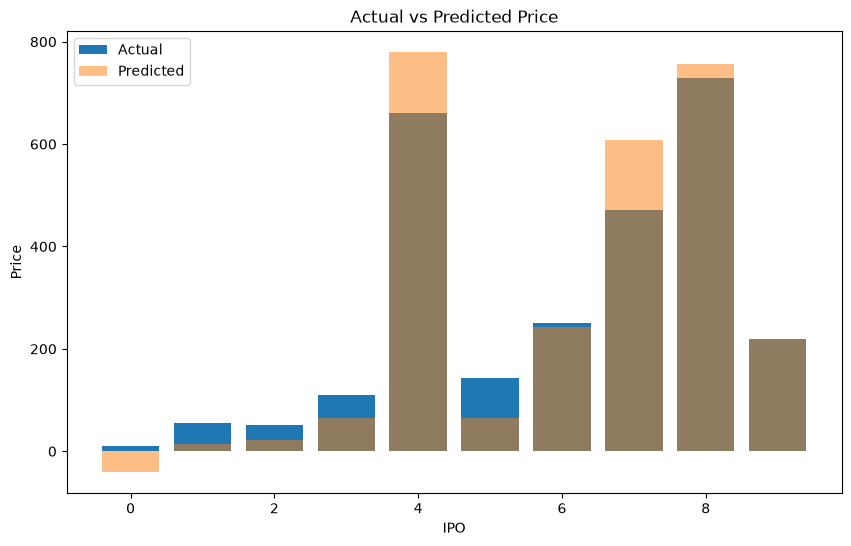

In [7]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))

plt.bar(range(10), y_test[:10], label="Actual")
plt.bar(range(10), lr_pred[:10], alpha=0.5, label="Predicted")

plt.xlabel("IPO")
plt.ylabel("Price")
plt.title("Actual vs Predicted Price")
plt.legend()

plt.show()

In [8]:
import joblib

joblib.dump(model, "linear_regression.pkl")

['linear_regression.pkl']